# Modelagem Baseline — Classificação de Abstracts Médicos

Este notebook testa arquiteturas baseline simples para a classificação de
abstracts médicos e avalia o resultado à luz do que a análise exploratória
revelou.

Ele é a continuação de `01_eda_nlp_hospital.ipynb`, mas é **autocontido**:
recarrega os dados brutos e refaz o pré-processamento com a mesma semente, de
modo que possa ser executado isoladamente. Nenhum módulo de `src/` é importado.

## O que muda por causa da EDA

A exploração mostrou que o corpus é **multirrótulo achatado**: ~26% dos
abstracts têm mais de um rótulo válido, e o teto teórico de F1-macro para
qualquer modelo de rótulo único é de aproximadamente **0,78**, não 1,0.

Isso muda a forma de ler os resultados aqui. Além das métricas convencionais,
a seção 8 separa duas coisas que o F1-macro mistura:

- erro de **modelo** — quando ele escolhe uma condição que o abstract não
  discute;
- erro de **gabarito** — quando ele escolhe uma condição correta, mas não a
  que aquela linha específica registrou.

> **Escopo.** Este notebook é exploratório e não representa o pipeline de
> produção, que vive em `src/` e é orquestrado por Airflow.

**Atualização — o que aconteceu depois deste diagnóstico.** O plano de
evolução derivado desta análise (`docs/plano_melhoria_f1.md`) concluiu que
perseguir esse teto de rótulo único era o problema errado a resolver. O
pipeline de produção implementa em vez disso a reformulação multilabel
documentada em `01_eda_nlp_hospital.ipynb` (seção 7): cinco classificadores
binários independentes (`OneVsRestClassifier`, em `src/models/classifier.py`),
um por categoria, que podem selecionar mais de um rótulo por abstract. As
seções seguintes ficam como registro do diagnóstico single-label que motivou
essa decisão — não são mais o estado da arte do projeto.

## 1. Bibliotecas

In [1]:
# torch (opcional; usado só pelo baseline experimental de BERT em outro lugar
# do projeto) precisa carregar antes do pandas: no Windows, a DLL nativa do
# torch falha ao inicializar se o pandas reivindicar o caminho de busca de
# DLLs do processo primeiro.
try:
    import torch  # noqa: F401
except ImportError:
    pass

# Manipulação de dados
from collections import Counter
from html import escape
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

# Visualização
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Processamento de texto
import nltk
from nltk.corpus import stopwords
import spacy
from unidecode import unidecode

# Modelagem
import sklearn
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 2. Configuração

A semente e o tamanho da amostra são os mesmos do notebook `01`, garantindo que
os dois trabalhem exatamente sobre o mesmo recorte dos dados.

In [2]:
RANDOM_STATE = 42
WORKING_SAMPLE_SIZE = 6000
TEST_SIZE = 0.2
TEXT_COLUMN = "medical_abstract"
TARGET_ID_COLUMN = "condition_label"
TARGET_COLUMN = "condition_name"
SPACY_MODEL = "en_core_web_sm"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists() and (PROJECT_ROOT.parent / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_PATH = REPORT_DIR / "baseline_modelagem_nlp_hospital.html"

REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "medical_tc_train.csv"
TEST_PATH = DATA_DIR / "medical_tc_test.csv"
LABELS_PATH = DATA_DIR / "medical_tc_labels.csv"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Relatório HTML: {REPORT_PATH}")

Projeto: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge
Relatório HTML: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\reports\baseline_modelagem_nlp_hospital.html


## 3. Funções auxiliares

Concentradas nesta seção, com responsabilidade única e docstrings objetivas.
As funções de pré-processamento repetem as do notebook `01` de propósito: cada
notebook precisa rodar sozinho.

In [3]:
def normalize_text(text: str) -> str:
    """Normaliza unicode, converte para minúsculas e colapsa espaços.

    Parameters
    ----------
    text:
        Texto bruto de entrada.

    Returns
    -------
    str
        Texto com acentos normalizados, minúsculas e espaços simples.
    """
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = unidecode(unicodedata.normalize("NFKD", text))
    return re.sub(r"\s+", " ", text)


def load_stopwords(language: str = "english") -> set[str]:
    """Carrega stopwords do NLTK com fallback determinístico.

    Parameters
    ----------
    language:
        Idioma das stopwords no NLTK.

    Returns
    -------
    set[str]
        Conjunto de stopwords usado no pré-processamento.
    """
    try:
        return set(stopwords.words(language))
    except LookupError:
        try:
            nltk.download("stopwords", quiet=True)
            return set(stopwords.words(language))
        except Exception:
            return set(ENGLISH_STOP_WORDS)


def load_spacy_pipeline(model_name: str = SPACY_MODEL):
    """Carrega o modelo spaCy usado na lematização.

    Parameters
    ----------
    model_name:
        Nome do modelo spaCy instalado.

    Returns
    -------
    tuple
        Objeto spaCy carregado e descrição legível do modelo usado.
    """
    try:
        nlp = spacy.load(model_name, disable=["ner", "parser"])
        return nlp, model_name
    except OSError:
        nlp = spacy.blank("en")
        return nlp, "spacy.blank('en') - fallback sem lematizador estatístico"


def clean_text(text: str, stop_words: set[str], nlp, remove_numbers: bool = False) -> str:
    """Limpa, tokeniza, remove stopwords e lematiza um texto.

    Parameters
    ----------
    text:
        Texto bruto de entrada.
    stop_words:
        Conjunto de stopwords.
    nlp:
        Pipeline spaCy.
    remove_numbers:
        Define se tokens numéricos devem ser removidos.

    Returns
    -------
    str
        Texto pré-processado, reconstruído a partir dos tokens úteis.
    """
    text = normalize_text(text)
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    doc = nlp(text)
    tokens = []
    for token in doc:
        lemma = token.lemma_.strip() if token.lemma_ else token.text
        lemma = lemma.lower().strip()
        if not lemma or lemma in stop_words or len(lemma) <= 1:
            continue
        if remove_numbers and lemma.isnumeric():
            continue
        tokens.append(lemma)
    return " ".join(tokens)


def make_stratified_sample(data: pd.DataFrame, n_rows: int, target_col: str) -> pd.DataFrame:
    """Retorna amostra estratificada quando a base é maior que n_rows.

    Parameters
    ----------
    data:
        DataFrame de entrada.
    n_rows:
        Número máximo de linhas desejado.
    target_col:
        Coluna de classe usada na estratificação.

    Returns
    -------
    pd.DataFrame
        Base completa ou amostra estratificada.
    """
    if n_rows is None or len(data) <= n_rows:
        return data.copy()
    _, sample = train_test_split(
        data,
        test_size=n_rows,
        stratify=data[target_col],
        random_state=RANDOM_STATE,
    )
    return sample.reset_index(drop=True)


def evaluate_model(model_name: str, y_true: pd.Series, y_pred: np.ndarray) -> tuple[dict, pd.DataFrame]:
    """Calcula métricas agregadas e por classe de um classificador.

    Parameters
    ----------
    model_name:
        Nome usado na tabela comparativa.
    y_true:
        Rótulos verdadeiros.
    y_pred:
        Rótulos previstos.

    Returns
    -------
    tuple[dict, pd.DataFrame]
        Linha de métricas agregadas e relatório detalhado por classe.
    """
    weighted = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    macro = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    report = pd.DataFrame(classification_report(y_true, y_pred, zero_division=0, output_dict=True)).T
    class_report = report.loc[[label for label in sorted(y_true.unique()) if label in report.index]].copy()
    minority_classes = y_true.value_counts().tail(2).index.tolist()
    minority_recall = class_report.loc[class_report.index.intersection(minority_classes), "recall"].mean()
    row = {
        "modelo": model_name,
        "weighted_precision": weighted[0],
        "weighted_recall": weighted[1],
        "weighted_f1": weighted[2],
        "macro_precision": macro[0],
        "macro_recall": macro[1],
        "macro_f1": macro[2],
        "recall_medio_classes_minoritarias": minority_recall,
        "observacao_classes_minoritarias": (
            "acompanhar de perto; métrica ponderada pode mascarar desempenho"
            if minority_recall < weighted[1]
            else "recall minoritário próximo da média ponderada no split avaliado"
        ),
    }
    return row, class_report


def plot_confusion(y_true: pd.Series, y_pred: np.ndarray, title: str, output_path: Path) -> None:
    """Plota e salva uma matriz de confusão.

    Parameters
    ----------
    y_true:
        Rótulos verdadeiros.
    y_pred:
        Rótulos previstos.
    title:
        Título do gráfico.
    output_path:
        Caminho de imagem para salvar o gráfico.
    """
    labels_order = sorted(y_true.unique())
    matrix = confusion_matrix(y_true, y_pred, labels=labels_order)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()

## 4. Dados e pré-processamento

Reproduz exatamente o recorte do notebook `01`: mesma consolidação de treino e
teste oficiais, mesma amostra estratificada, mesma semente.

In [4]:
required_files = [TRAIN_PATH, TEST_PATH, LABELS_PATH]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Arquivos esperados não encontrados: "
        + ", ".join(str(path) for path in missing_files)
        + ". Baixe o dataset do Kaggle e mantenha os CSVs em data/raw."
    )

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
labels = pd.read_csv(LABELS_PATH)

df = pd.concat(
    [
        train_raw.assign(source_split="kaggle_train"),
        test_raw.assign(source_split="kaggle_test"),
    ],
    ignore_index=True,
)
df = df.merge(labels, on=TARGET_ID_COLUMN, how="left")
df["text_original"] = df[TEXT_COLUMN].astype("string").fillna("")

class_distribution = (
    df[TARGET_COLUMN].value_counts(dropna=False).rename_axis("classe").reset_index(name="registros")
)

stop_words = load_stopwords("english")
nlp, spacy_model_used = load_spacy_pipeline(SPACY_MODEL)
print(f"Modelo spaCy usado: {spacy_model_used}")

work_df = make_stratified_sample(df, WORKING_SAMPLE_SIZE, TARGET_COLUMN).copy()
work_df["text_original"] = work_df[TEXT_COLUMN].astype("string").fillna("")
work_df["text_clean"] = [
    clean_text(text, stop_words=stop_words, nlp=nlp, remove_numbers=False)
    for text in work_df["text_original"]
]

print(f"Registros consolidados: {len(df):,}")
print(f"Registros na amostra de trabalho: {len(work_df):,}")
display(work_df[[TARGET_COLUMN, "text_original", "text_clean"]].head())

C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\.venv\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Modelo spaCy usado: en_core_web_sm


Registros consolidados: 14,438
Registros na amostra de trabalho: 6,000


,condition_name,text_original,text_clean
0,general pathological conditions,"Episodic hyperammonemia in adult siblings with hyperornithinemia, hyperammonemia, and homocitrullinuria syndrome. A ...",episodic hyperammonemia adult sibling hyperornithinemia hyperammonemia homocitrullinuria syndrome 39 year old man 42...
1,general pathological conditions,Repair of pelvic fracture posterior urethral defects using an elaborated perineal approach: experience with 74 cases...,repair pelvic fracture posterior urethral defect use elaborate perineal approach experience 74 case total 74 patient...
2,neoplasms,Etoposide. Current and future status. Etoposide (VP-16-213) is an antineoplastic agent with demonstrated efficacy ag...,etoposide current future status etoposide vp 16 213 antineoplastic agent demonstrate efficacy broad spectrum human m...
3,neoplasms,Potential role of beta-carotene in prevention of oral cancer. Recent data suggests that retinoids and carotenoids ma...,potential role beta carotene prevention oral cancer recent datum suggest retinoid carotenoid may effective reverse p...
4,general pathological conditions,Sun-induced freckles in children and young adults. A correlation of clinical and histopathologic features. Sun-induc...,sun induce freckle child young adult correlation clinical histopathologic feature sun induce freckle risk factor epi...


## 5. Separação treino e teste

A separação acontece **antes** da vetorização, e o TF-IDF é ajustado apenas no
treino. Esta ordem evita que estatísticas de frequência do conjunto de teste
vazem para a representação — um erro comum e silencioso.

A hiperparametrização do TF-IDF (`max_features=5000`, `ngram_range=(1, 2)`)
não é arbitrária: a seção 10.3 do notebook `01` mostrou que 5.000 termos cobrem
~90% do corpus, e a 10.5 mostrou que bigramas capturam entidades clínicas reais.

In [5]:
model_df = work_df.loc[work_df["text_clean"].str.strip().ne("")].copy()

X_train, X_test, y_train, y_test = train_test_split(
    model_df["text_clean"],
    model_df[TARGET_COLUMN],
    test_size=TEST_SIZE,
    stratify=model_df[TARGET_COLUMN],
    random_state=RANDOM_STATE,
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Treino: {X_train.shape[0]:,} registros")
print(f"Teste: {X_test.shape[0]:,} registros")
print(f"Matriz TF-IDF de treino: {X_train_tfidf.shape}")
print("O TF-IDF foi ajustado somente no treino, evitando vazamento de dados.")

Treino: 4,800 registros
Teste: 1,200 registros
Matriz TF-IDF de treino: (4800, 5000)
O TF-IDF foi ajustado somente no treino, evitando vazamento de dados.


## 6. Modelagem baseline

Três arquiteturas, com papéis diferentes:

- **Regressão Logística** — a referência natural para TF-IDF esparso e de alta
  dimensão. É o candidato sério.
- **Random Forest** — comparativo exploratório. Árvores tendem a sofrer em
  espaços esparsos e amplos, onde cada feature isolada carrega pouco sinal.
- **Gradient Boosting** — também comparativo. Exige seleção de features via
  chi² e conversão para matriz densa, o que por si só já sinaliza o desencaixe
  entre o modelo e a representação.

**Nota de escopo.** As três arquiteturas abaixo são treinadas como
classificadores single-label (`y` de uma única coluna, uma condição por
abstract) — uma simplificação exploratória deliberada para isolar o efeito do
algoritmo, mantida aqui como comparação histórica/metodológica. O pipeline de
produção não usa essa formulação: ele treina os mesmos tipos de modelo dentro
de um `OneVsRestClassifier` multilabel (ver `01_eda_nlp_hospital.ipynb` seção
7 e `src/models/classifier.py`).

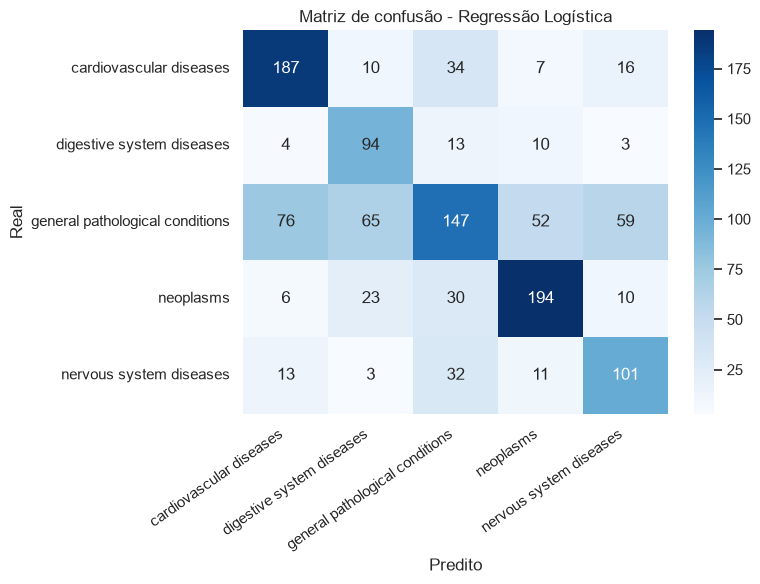

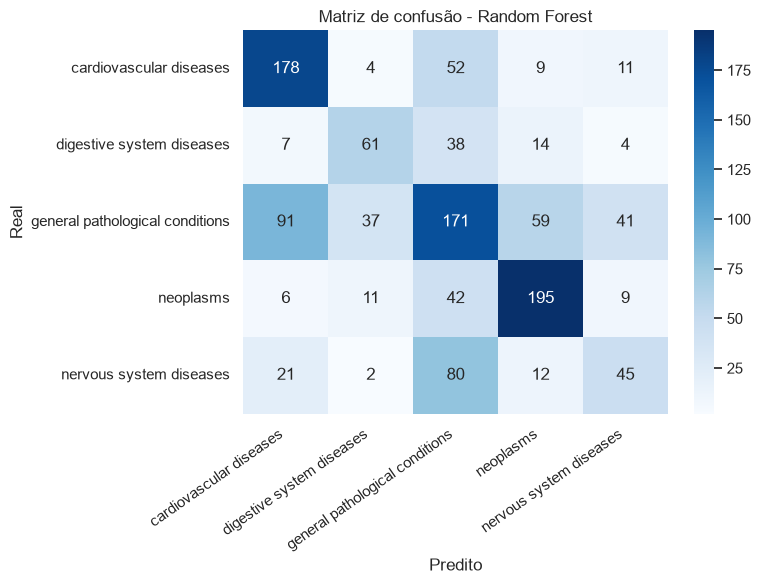

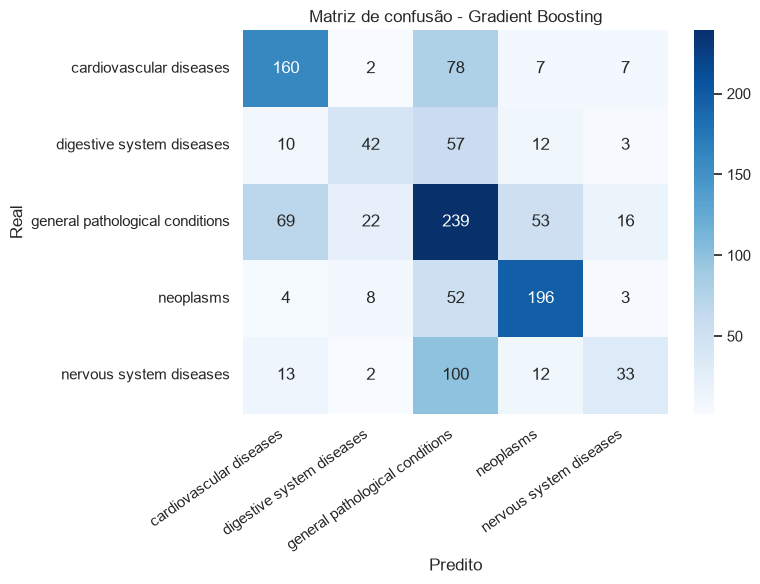

In [6]:
models = {
    "Regressão Logística": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=160,
        max_depth=None,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

metric_rows = []
class_reports = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    predictions[model_name] = y_pred
    row, class_report = evaluate_model(model_name, y_test, y_pred)
    metric_rows.append(row)
    class_reports[model_name] = class_report
    model_slug = re.sub(r"[^a-z0-9]+", "_", unidecode(model_name.lower())).strip("_")
    plot_confusion(
        y_test, y_pred, f"Matriz de confusão - {model_name}",
        FIGURE_DIR / f"confusion_{model_slug}.png",
    )

# Gradient Boosting não lida bem com matrizes TF-IDF esparsas e amplas.
# Para viabilizar o comparativo, aplicamos seleção chi2 e convertemos apenas
# as melhores features para matriz densa.
gb_k = min(800, X_train_tfidf.shape[1])
selector = SelectKBest(score_func=chi2, k=gb_k)
X_train_gb = selector.fit_transform(X_train_tfidf, y_train).toarray()
X_test_gb = selector.transform(X_test_tfidf).toarray()

gb_model = GradientBoostingClassifier(
    n_estimators=80,
    learning_rate=0.08,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb_model.fit(X_train_gb, y_train)
gb_pred = gb_model.predict(X_test_gb)
predictions["Gradient Boosting"] = gb_pred
row, class_report = evaluate_model("Gradient Boosting", y_test, gb_pred)
metric_rows.append(row)
class_reports["Gradient Boosting"] = class_report
plot_confusion(
    y_test, gb_pred, "Matriz de confusão - Gradient Boosting",
    FIGURE_DIR / "confusion_gradient_boosting.png",
)

## 7. Avaliação dos modelos

Em contexto de apoio à priorização, o **recall por classe** merece atenção
especial: métricas ponderadas podem mascarar desempenho ruim justamente nas
classes menos frequentes.

In [7]:
metrics_df = pd.DataFrame(metric_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
metric_columns = [
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "recall_medio_classes_minoritarias",
]
display(metrics_df.assign(**{col: metrics_df[col].round(4) for col in metric_columns}))

for model_name, report in class_reports.items():
    print(f"\nPrecision / recall / F1 por classe - {model_name}")
    display(report[["precision", "recall", "f1-score", "support"]].round(4))

best_model = metrics_df.iloc[0]["modelo"]
best_macro_f1 = float(metrics_df.iloc[0]["macro_f1"])
print(f"\nModelo baseline mais promissor neste split: {best_model} (macro-F1 = {best_macro_f1:.4f})")

,modelo,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1,recall_medio_classes_minoritarias,observacao_classes_minoritarias
0,Regressão Logística,0.6056,0.6025,0.5923,0.5905,0.6463,0.6064,0.6947,recall minoritário próximo da média ponderada no split avaliado
1,Random Forest,0.5300,0.5417,0.5327,0.5296,0.5288,0.5254,0.3866,acompanhar de perto; métrica ponderada pode mascarar desempenho
2,Gradient Boosting,0.5649,0.5583,0.5459,0.5729,0.5038,0.5167,0.2725,acompanhar de perto; métrica ponderada pode mascarar desempenho



Precision / recall / F1 por classe - Regressão Logística


,precision,recall,f1-score,support
cardiovascular diseases,0.6538,0.7362,0.6926,254.0
digestive system diseases,0.4821,0.7581,0.5893,124.0
general pathological conditions,0.5742,0.3684,0.4489,399.0
neoplasms,0.7080,0.7376,0.7225,263.0
nervous system diseases,0.5344,0.6312,0.5788,160.0



Precision / recall / F1 por classe - Random Forest


,precision,recall,f1-score,support
cardiovascular diseases,0.5875,0.7008,0.6391,254.0
digestive system diseases,0.5304,0.4919,0.5105,124.0
general pathological conditions,0.4465,0.4286,0.4373,399.0
neoplasms,0.6747,0.7414,0.7065,263.0
nervous system diseases,0.4091,0.2812,0.3333,160.0



Precision / recall / F1 por classe - Gradient Boosting


,precision,recall,f1-score,support
cardiovascular diseases,0.6250,0.6299,0.6275,254.0
digestive system diseases,0.5526,0.3387,0.4200,124.0
general pathological conditions,0.4544,0.5990,0.5168,399.0
neoplasms,0.7000,0.7452,0.7219,263.0
nervous system diseases,0.5323,0.2062,0.2973,160.0



Modelo baseline mais promissor neste split: Regressão Logística (macro-F1 = 0.6064)


**Leitura.** A Regressão Logística lidera, como esperado para TF-IDF esparso.
Random Forest e Gradient Boosting ficam bem atrás — o resultado confirma a
hipótese da seção 6: modelos de árvore não são naturais para essa representação.

Duas observações que orientam a próxima seção:

- Nenhum modelo passa muito de **0,60 de macro-F1**, e a distância entre
  arquiteturas muito diferentes é pequena. Quando modelos de famílias distintas
  empacam no mesmo patamar, a limitação raramente está no modelo.
- A classe `general pathological conditions` tem o pior recall em todos eles,
  exatamente como a EDA previu.

## 8. O F1 baixo é do modelo ou do gabarito?

Esta é a seção que conecta a modelagem ao achado da EDA.

O notebook `01` mostrou que ~26% dos abstracts têm mais de um rótulo válido.
Quando o modelo responde uma condição que o abstract realmente discute, mas não
a que aquela linha registrou, o F1-macro conta como erro — embora a resposta
esteja clinicamente correta.

Medimos isso com duas métricas:

- **acurácia exata** — o critério convencional, `predição == rótulo da linha`;
- **acurácia "in-set"** — `predição ∈ conjunto de rótulos válidos do abstract`.

E decompomos o acerto pela ambiguidade de cada abstract.

In [8]:
label_sets_by_text = df.groupby(TEXT_COLUMN)[TARGET_COLUMN].agg(set)
n_labels_per_text = label_sets_by_text.apply(len)

test_texts_full = model_df.loc[X_test.index, TEXT_COLUMN]
best_predictions = predictions[best_model]

y_test_reset = y_test.reset_index(drop=True)
exact_match = pd.Series(best_predictions).reset_index(drop=True) == y_test_reset
in_valid_set = pd.Series(
    [prediction in label_sets_by_text[text] for prediction, text in zip(best_predictions, test_texts_full)]
).reset_index(drop=True)
n_labels_test = test_texts_full.map(n_labels_per_text).reset_index(drop=True)

error_decomposition = (
    pd.DataFrame({"rotulos_validos_no_corpus": n_labels_test, "acerto_exato": exact_match})
    .groupby("rotulos_validos_no_corpus")["acerto_exato"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "acuracia", "count": "abstracts"})
    .round(3)
)
print(f"Acurácia do baseline {best_model}, decomposta pela ambiguidade do abstract:")
display(error_decomposition)

exact_accuracy = float(exact_match.mean())
in_set_accuracy = float(in_valid_set.mean())
wrongly_penalized = float((in_valid_set & ~exact_match).mean())

print(f"\nAcurácia exata (predição == rótulo da linha):        {exact_accuracy:.3f}")
print(f"Acurácia in-set (predição entre os rótulos válidos do texto): {in_set_accuracy:.3f}")
print(
    f"\n{wrongly_penalized:.1%} do conjunto de teste foi classificado CORRETAMENTE e contado"
    " como erro, porque o gabarito daquela linha registrou outro rótulo igualmente"
    " válido do mesmo abstract."
)

Acurácia do baseline Regressão Logística, decomposta pela ambiguidade do abstract:


,acuracia,abstracts
rotulos_validos_no_corpus,,
1,0.778,658
2,0.410,459
3,0.284,81
4,0.000,2



Acurácia exata (predição == rótulo da linha):        0.603
Acurácia in-set (predição entre os rótulos válidos do texto): 0.848

24.5% do conjunto de teste foi classificado CORRETAMENTE e contado como erro, porque o gabarito daquela linha registrou outro rótulo igualmente válido do mesmo abstract.


,metrica,valor
0,Acurácia exata,0.6025
1,Acurácia in-set,0.8475
2,Macro-F1,0.6064
3,"Teto teórico de macro-F1 (oráculo, ver notebook 01)",0.7800


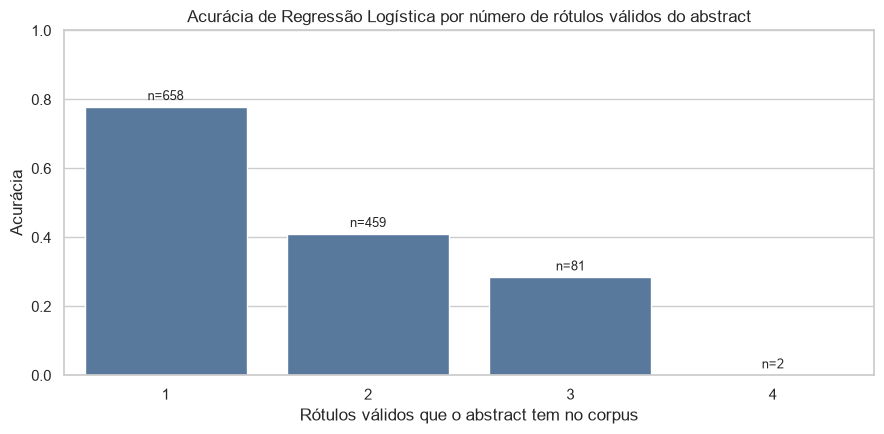

In [9]:
comparison = pd.DataFrame(
    [
        {"metrica": "Acurácia exata", "valor": round(exact_accuracy, 4)},
        {"metrica": "Acurácia in-set", "valor": round(in_set_accuracy, 4)},
        {"metrica": "Macro-F1", "valor": round(best_macro_f1, 4)},
        {"metrica": "Teto teórico de macro-F1 (oráculo, ver notebook 01)", "valor": 0.78},
    ]
)
display(comparison)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = error_decomposition.reset_index()
sns.barplot(data=plot_data, x="rotulos_validos_no_corpus", y="acuracia", ax=ax, color="#4C78A8")
ax.set_title(f"Acurácia de {best_model} por número de rótulos válidos do abstract")
ax.set_xlabel("Rótulos válidos que o abstract tem no corpus")
ax.set_ylabel("Acurácia")
ax.set_ylim(0, 1)
for index, row_data in plot_data.iterrows():
    ax.text(index, row_data["acuracia"] + 0.02, f"n={int(row_data['abstracts'])}", ha="center", fontsize=9)
plt.tight_layout()
error_decomposition_path = FIGURE_DIR / "accuracy_by_label_count.png"
fig.savefig(error_decomposition_path, dpi=140, bbox_inches="tight")
plt.show()

**Leitura — e a conclusão central deste notebook.**

O gráfico mostra uma queda acentuada: o modelo acerta bem nos abstracts de
rótulo único e despenca conforme a ambiguidade cresce. Não é que ele "entenda
menos" os textos ambíguos — é que neles a chance de escolher exatamente o
rótulo registrado é matematicamente menor.

A diferença entre acurácia exata e acurácia in-set quantifica o custo: uma
fatia relevante do teste é resposta certa contada como erro.

Isso reposiciona todo o resultado. Um macro-F1 de ~0,60 num problema cujo teto
é 0,78 não é um modelo ruim — é um modelo razoável num benchmark com gabarito
ambíguo.

**O que essa métrica motivou, na prática.** Esta seção foi o diagnóstico que
levou à decisão de reformular o problema como multilabel, e não à busca por um
modelo de maior capacidade para o subconjunto de rótulo único. Em produção,
`in_set_accuracy` foi substituída por avaliação multilabel real
(`src/evaluation/evaluate.py`): `hamming_loss`, `jaccard_samples`,
`subset_accuracy` e precision/recall/F1 por rótulo, medidos contra o conjunto
completo de labels válidos por abstract — não contra uma única linha
achatada.

## 9. Arquitetura teórica inicial para o MVP

Proposta derivada dos achados, não solução definitiva.

In [10]:
architecture_steps = pd.DataFrame(
    [
        {"etapa": "Entrada", "descricao": "Texto médico digitado, enviado por formulário ou recebido por integração."},
        {"etapa": "Pré-processamento", "descricao": "Normalização, limpeza leve, stopwords e lematização documentada."},
        {"etapa": "Vetorização", "descricao": "TF-IDF (max_features=5000, 1-2 gramas) ajustado somente no treino e persistido com o modelo."},
        {"etapa": "Classificador", "descricao": f"Baseline candidato: {best_model}, sujeito a validação cruzada e comparação futura."},
        {"etapa": "Saída", "descricao": "Conjunto de rótulos cujo score cruza um threshold (ex.: 0.5), cada categoria avaliada de forma independente — não apenas a classe de maior score."},
        {"etapa": "Endpoint futuro", "descricao": "API REST para predição em tempo real, com validação de entrada e monitoramento."},
        {"etapa": "Refatoração antes de produção", "descricao": "Separar pipeline, versionar artefatos, testar, monitorar drift e revisar riscos clínicos."},
    ]
)
display(architecture_steps)

production_candidates = pd.DataFrame(
    [
        {"biblioteca": "pandas", "uso": "ingestão offline e auditoria de dados"},
        {"biblioteca": "scikit-learn", "uso": "pipeline TF-IDF + classificador baseline"},
        {"biblioteca": "joblib", "uso": "persistência do pipeline treinado"},
        {"biblioteca": "FastAPI", "uso": "endpoint de predição"},
        {"biblioteca": "prometheus-client", "uso": "métricas de API em produção"},
        {"biblioteca": "onnxruntime", "uso": "redução de latência do classificador"},
    ]
)
display(production_candidates)

,etapa,descricao
0,Entrada,"Texto médico digitado, enviado por formulário ou recebido por integração."
1,Pré-processamento,"Normalização, limpeza leve, stopwords e lematização documentada."
2,Vetorização,"TF-IDF (max_features=5000, 1-2 gramas) ajustado somente no treino e persistido com o modelo."
3,Classificador,"Baseline candidato: Regressão Logística, sujeito a validação cruzada e comparação futura."
4,Saída,"Conjunto de rótulos cujo score cruza um threshold (ex.: 0.5), cada categoria avaliada de forma independente — não ap..."
5,Endpoint futuro,"API REST para predição em tempo real, com validação de entrada e monitoramento."
6,Refatoração antes de produção,"Separar pipeline, versionar artefatos, testar, monitorar drift e revisar riscos clínicos."


,biblioteca,uso
0,pandas,ingestão offline e auditoria de dados
1,scikit-learn,pipeline TF-IDF + classificador baseline
2,joblib,persistência do pipeline treinado
3,FastAPI,endpoint de predição
4,prometheus-client,métricas de API em produção
5,onnxruntime,redução de latência do classificador


**Nota sobre a saída do modelo.** A EDA justifica uma decisão de design: como
~26% dos abstracts têm mais de uma condição válida, expor o **score por classe**
(e não apenas o argmax) é mais honesto e mais útil para priorização. Em
produção essa ideia foi além de uma leitura de top-2: o modelo é
genuinamente multilabel e seleciona todo rótulo cujo score cruze o threshold
configurado, não um número fixo de categorias.

## 10. Principais achados e próximos passos

In [11]:
findings = [
    f"O melhor baseline foi {best_model}, com macro-F1 de {best_macro_f1:.4f} neste split.",
    "Random Forest e Gradient Boosting ficaram bem atrás, confirmando que modelos de árvore não são naturais para TF-IDF esparso e amplo.",
    "Arquiteturas de famílias muito diferentes convergiram para o mesmo patamar (~0,60), sinal de que a limitação não está na escolha do modelo.",
    f"A acurácia in-set ({in_set_accuracy:.3f}) é muito superior à exata ({exact_accuracy:.3f}): o modelo acerta a condição com frequência bem maior do que a métrica convencional registra.",
    f"{wrongly_penalized:.1%} do teste é resposta correta contada como erro, por causa do achatamento multirrótulo documentado no notebook 01.",
    "A acurácia cai monotonicamente conforme cresce o número de rótulos válidos do abstract, confirmando a hipótese da EDA.",
    "'general pathological conditions' tem o pior recall em todos os modelos, como a EDA antecipou pela análise de co-ocorrência e de centroides.",
    "A análise usa abstracts médicos públicos como proxy acadêmico; não é validação clínica.",
]

for item in findings:
    print(f"- {item}")

- O melhor baseline foi Regressão Logística, com macro-F1 de 0.6064 neste split.
- Random Forest e Gradient Boosting ficaram bem atrás, confirmando que modelos de árvore não são naturais para TF-IDF esparso e amplo.
- Arquiteturas de famílias muito diferentes convergiram para o mesmo patamar (~0,60), sinal de que a limitação não está na escolha do modelo.
- A acurácia in-set (0.848) é muito superior à exata (0.603): o modelo acerta a condição com frequência bem maior do que a métrica convencional registra.
- 24.5% do teste é resposta correta contada como erro, por causa do achatamento multirrótulo documentado no notebook 01.
- A acurácia cai monotonicamente conforme cresce o número de rótulos válidos do abstract, confirmando a hipótese da EDA.
- 'general pathological conditions' tem o pior recall em todos os modelos, como a EDA antecipou pela análise de co-ocorrência e de centroides.
- A análise usa abstracts médicos públicos como proxy acadêmico; não é validação clínica.


### Próximos passos

O que este notebook mostrou empiricamente motivou três direções, detalhadas
em `docs/plano_melhoria_f1.md` — e o que de fato aconteceu com cada uma:

1. **Buscar hiperparâmetros com validação cruzada.** O split único de 20% usado
   aqui é sensível a ruído amostral; diferenças pequenas entre modelos não são
   conclusivas. Implementado no pipeline de produção.
2. **Reportar métricas honestas** junto do macro-F1 — a acurácia in-set e a
   decomposição por ambiguidade medidas na seção 8. Substituído em produção por
   avaliação multilabel real (`hamming_loss`, `jaccard_samples`,
   `subset_accuracy`, F1 por rótulo — `src/evaluation/evaluate.py`), que mede
   contra o conjunto completo de labels válidos em vez de aproximar por
   in-set/top-2.
3. ~~Atacar o subconjunto de rótulo único com um modelo de maior capacidade
   contextual.~~ **Não foi o caminho seguido.** Em vez de perseguir um modelo
   maior para um problema definido como single-label, o projeto reformulou o
   próprio problema como multilabel (`OneVsRestClassifier`, um binário por
   categoria — ver `01_eda_nlp_hospital.ipynb` seção 7 e
   `src/models/classifier.py`). O teto de ~0,78 medido aqui é um teto do
   *enunciado* single-label, não do domínio: deixa de existir quando o modelo
   pode responder mais de um rótulo.

### Limitações

- Amostra de trabalho de 6.000 registros, para manter a execução local viável.
- Split único de treino e teste, sem validação cruzada — adequado para um
  comparativo exploratório, insuficiente para decisão final de arquitetura.
- Gradient Boosting exigiu seleção de features e conversão densa, o que o
  coloca em condições diferentes dos demais.
- Nenhum resultado aqui substitui validação clínica ou revisão humana.

## 11. Relatório de modelagem em HTML

In [12]:
def image_tag(path: Path, alt: str) -> str:
    """Retorna uma tag HTML de imagem quando o arquivo existe."""
    if not path.exists():
        return f"<p><em>Figura não encontrada: {escape(str(path))}</em></p>"
    relative = path.relative_to(REPORT_DIR).as_posix()
    return f'<figure><img src="{escape(relative)}" alt="{escape(alt)}"><figcaption>{escape(alt)}</figcaption></figure>'


library_versions = pd.DataFrame(
    [
        {"biblioteca": "python", "versao": "3.11"},
        {"biblioteca": "pandas", "versao": pd.__version__},
        {"biblioteca": "numpy", "versao": np.__version__},
        {"biblioteca": "scikit-learn", "versao": sklearn.__version__},
        {"biblioteca": "matplotlib", "versao": matplotlib.__version__},
        {"biblioteca": "seaborn", "versao": sns.__version__},
        {"biblioteca": "nltk", "versao": nltk.__version__},
        {"biblioteca": "spaCy", "versao": spacy.__version__},
        {"biblioteca": "spaCy model", "versao": spacy_model_used},
    ]
)

confusion_html = "\n".join(
    image_tag(path, f"Matriz de confusão - {path.stem.replace('confusion_', '').replace('_', ' ')}")
    for path in sorted(FIGURE_DIR.glob("confusion_*.png"))
)

float_format = lambda value: f"{value:.4f}" if isinstance(value, float) else str(value)

html = f"""
<!doctype html>
<html lang="pt-BR">
<head>
  <meta charset="utf-8">
  <title>Relatório de Modelagem Baseline — Abstracts Médicos</title>
  <style>
    body {{ font-family: Arial, sans-serif; line-height: 1.5; margin: 40px; color: #222; }}
    h1, h2 {{ color: #1f4e79; }}
    table {{ border-collapse: collapse; width: 100%; margin: 16px 0; }}
    th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
    th {{ background: #f2f5f7; }}
    img {{ max-width: 100%; height: auto; border: 1px solid #ddd; }}
    figure {{ margin: 20px 0; }}
    figcaption {{ font-size: 0.9em; color: #555; }}
    .note {{ background: #fff8e1; padding: 12px; border-left: 4px solid #d39e00; }}
    .key {{ background: #e8f4fd; padding: 12px; border-left: 4px solid #1f4e79; }}
  </style>
</head>
<body>
  <h1>Relatório de Modelagem Baseline — Classificação de Abstracts Médicos</h1>
  <p class="note">Relatório exploratório. Complementa o relatório de EDA em <code>eda_nlp_hospital.html</code>. Não representa o pipeline de produção nem validação clínica.</p>

  <h2>1. Setup experimental</h2>
  <ul>
    <li>Amostra estratificada de {WORKING_SAMPLE_SIZE:,} registros do corpus consolidado.</li>
    <li>Split estratificado de {TEST_SIZE:.0%} para teste, com <code>random_state={RANDOM_STATE}</code>.</li>
    <li>TF-IDF com <code>max_features=5000</code>, <code>ngram_range=(1, 2)</code>, ajustado somente no treino.</li>
  </ul>

  <h2>2. Comparação entre arquiteturas baseline</h2>
  {metrics_df.to_html(index=False, float_format=float_format)}
  {confusion_html}

  <h2>3. Modelo baseline mais promissor</h2>
  <p>Modelo candidato neste split: <strong>{escape(str(best_model))}</strong>, com macro-F1 de <strong>{best_macro_f1:.4f}</strong>. A justificativa considera macro-F1 e macro-recall, para reduzir o risco de métricas ponderadas esconderem desempenho ruim nas classes menores.</p>

  <h2>4. Diagnóstico: o teto do benchmark single-label</h2>
  <div class="key">
    <p>O corpus é multirrótulo achatado (ver relatório de EDA). Isso limita estruturalmente qualquer modelo que responda um único rótulo por abstract:</p>
    <ul>
      <li>Acurácia exata: <strong>{exact_accuracy:.3f}</strong></li>
      <li>Acurácia in-set (predição entre os rótulos válidos do abstract): <strong>{in_set_accuracy:.3f}</strong></li>
      <li><strong>{wrongly_penalized:.1%}</strong> do teste é resposta correta contada como erro.</li>
      <li>Teto teórico de macro-F1 para modelos de rótulo único: <strong>~0,78</strong></li>
    </ul>
    <p>Este teto é do enunciado single-label testado neste notebook, não do domínio: o pipeline de produção o contorna reformulando o problema como multilabel (seção 5).</p>
  </div>
  {error_decomposition.reset_index().to_html(index=False)}
  {image_tag(error_decomposition_path, "Acurácia por número de rótulos válidos do abstract")}

  <h2>5. Arquitetura proposta para o MVP (histórico) e o que foi construído</h2>
  <p>Esta arquitetura foi a proposta exploratória deste notebook. O pipeline de produção seguiu a mesma espinha dorsal (TF-IDF + classificador linear + API + ONNX), mas com o classificador envolvido por um <code>OneVsRestClassifier</code> multilabel — por isso a etapa "Saída" abaixo já reflete um conjunto de rótulos por threshold, não uma única classe.</p>
  {architecture_steps.to_html(index=False)}

  <h2>6. Bibliotecas usadas no desenvolvimento</h2>
  {library_versions.to_html(index=False)}

  <h2>7. Bibliotecas candidatas para produção</h2>
  {production_candidates.to_html(index=False)}

  <h2>8. Limitações e próximos passos</h2>
  <ul>
    <li>Split único de {TEST_SIZE:.0%}, sem validação cruzada: diferenças pequenas entre modelos não são conclusivas.</li>
    <li>Amostra de {WORKING_SAMPLE_SIZE:,} registros, não o corpus completo.</li>
    <li>Gradient Boosting exigiu seleção chi2 e conversão densa, ficando em condições diferentes dos demais.</li>
    <li>Plano de evolução detalhado em <code>docs/plano_melhoria_f1.md</code>; a direção que de fato foi seguida foi reformular o problema como multilabel (<code>OneVsRestClassifier</code>), não buscar um modelo maior para o subconjunto de rótulo único — ver <code>01_eda_nlp_hospital.ipynb</code> seção 7 e <code>src/models/classifier.py</code>.</li>
  </ul>
</body>
</html>
"""

REPORT_PATH.write_text(html, encoding="utf-8")
print(f"Relatório salvo em: {REPORT_PATH}")

Relatório salvo em: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\reports\baseline_modelagem_nlp_hospital.html
